In [1]:
### The goal here is to build a toy dataset that validates the CWoLa approach, specifically the ability
### to compare inputs across two mixed samples (weakly supervised) and output a score that ranks the event 
### more similar to the signal region of 1 or more similar to the background region of 0. 

### explore limits of CWoLa: signal vs no signal, signal region definition misaligned
### view loss and accuracy plots

### AUC metric quantifies performance in original CWoLa paper

### ratios of each mixed sample not necessary for CWoLa, remains equal within sets

In [2]:
import torch

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# define data, 6-D space

background_events = 8000
signal_events = 2000

# background distribution
Xb = np.random.uniform(low=-10, high=10, size=(background_events, 6))
Xb = np.array(Xb, dtype=np.float32)
yb = np.zeros((len(Xb), 1), dtype=np.float32)

Xb_train, Xb_valtest, yb_train, yb_valtest = train_test_split(Xb, yb, test_size = 0.4)
Xb_val, Xb_test, yb_val, yb_test = train_test_split(Xb_valtest, yb_valtest, test_size=0.5)


# signal distribution
mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
cov_s = np.eye(6) # identity matrix for covariance
Xs = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
Xs = np.array(Xs, dtype=np.float32)
ys = np.ones((len(Xs), 1), dtype=np.float32)

Xs_train, Xs_valtest, ys_train, ys_valtest = train_test_split(Xs, ys, test_size = 0.4)
Xs_val, Xs_test, ys_val, ys_test = train_test_split(Xs_valtest, ys_valtest, test_size=0.5)

# guarantees that training, validation, and test have the same percentage of background vs signal points (90/10)
print(f"Background training set has {len(Xb_train)} events.")
print(f"Background validation set has {len(Xb_val)} events.")
print(f"Background test set has {len(Xb_test)} events.")
print(f"Signal training set has {len(Xs_train)} events.")
print(f"Signal validation set has {len(Xs_val)} events.")
print(f"Signal test set has {len(Xs_test)} events.")

X_train = np.vstack([Xb_train, Xs_train])
X_val = np.vstack([Xb_val, Xs_val])
X_test = np.vstack([Xb_test, Xs_test])
y_train = np.concatenate([yb_train, ys_train])
y_val = np.concatenate([yb_val, ys_val])
y_test = np.concatenate([yb_test, ys_test])

idx = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

idx = np.random.permutation(len(X_val))
X_val = X_val[idx]
y_val = y_val[idx]

idx = np.random.permutation(len(X_test))
X_test = X_test[idx]
y_test = y_test[idx]

Background training set has 4800 events.
Background validation set has 1600 events.
Background test set has 1600 events.
Signal training set has 1200 events.
Signal validation set has 400 events.
Signal test set has 400 events.


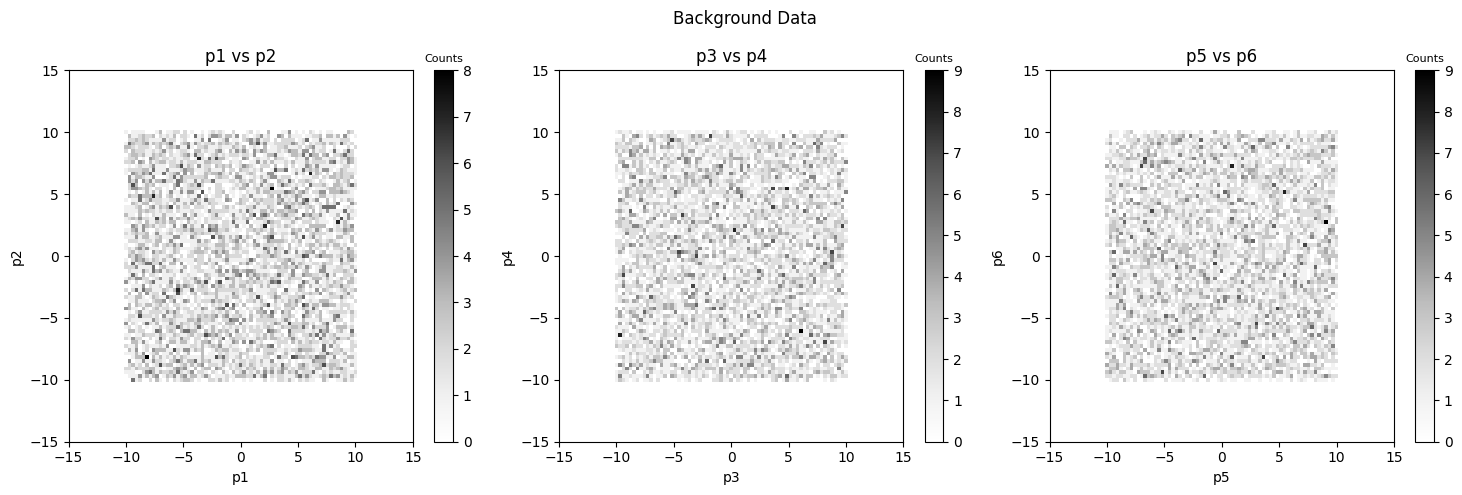

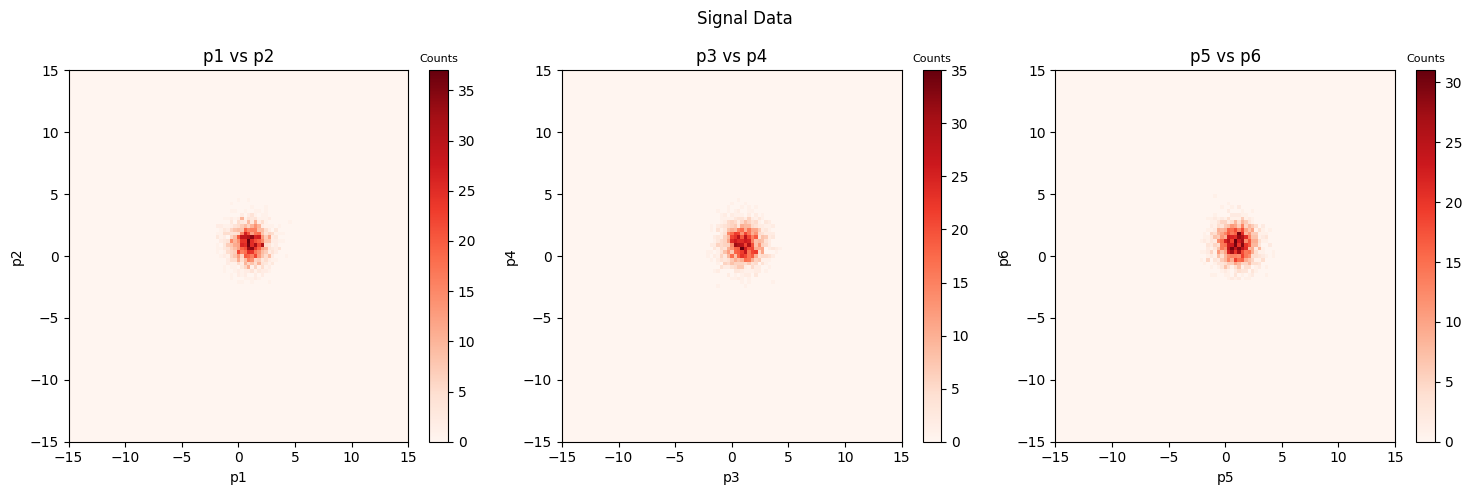

In [5]:
# DataFrames and plots

## background data

col_names = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6']
df_background = pd.DataFrame(Xb, columns=col_names)
bins = [np.linspace(-15,15,100), np.linspace(-15,15,100)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)
fig.suptitle('Background Data')
color = 'Greys'

h = axes[0].hist2d(df_background['p1'], df_background['p2'],
                   bins=bins, cmap=color)
axes[0].set_title('p1 vs p2')
axes[0].set_xlabel('p1', fontsize=10)
axes[0].set_ylabel('p2', fontsize=10)
c = fig.colorbar(h[3], ax=axes[0])
c.ax.set_title('Counts', fontsize=8)

h = axes[1].hist2d(df_background['p3'], df_background['p4'],
                   bins=bins, cmap=color)
axes[1].set_title('p3 vs p4')
axes[1].set_xlabel('p3', fontsize=10)
axes[1].set_ylabel('p4', fontsize=10)
c = fig.colorbar(h[3], ax=axes[1])
c.ax.set_title('Counts', fontsize=8)

h = axes[2].hist2d(df_background['p5'], df_background['p6'],
                   bins=bins, cmap=color)
axes[2].set_title('p5 vs p6')
axes[2].set_xlabel('p5', fontsize=10)
axes[2].set_ylabel('p6', fontsize=10)
c = fig.colorbar(h[3], ax=axes[2])
c.ax.set_title('Counts', fontsize=8)

plt.show()


## signal data

col_names = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6']
df_signal = pd.DataFrame(Xs, columns=col_names)


fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)
fig.suptitle('Signal Data')
color = 'Reds'

h = axes[0].hist2d(df_signal['p1'], df_signal['p2'],
                   bins=bins, cmap=color)
axes[0].set_title('p1 vs p2')
axes[0].set_xlabel('p1', fontsize=10)
axes[0].set_ylabel('p2', fontsize=10)
c = fig.colorbar(h[3], ax=axes[0])
c.ax.set_title('Counts', fontsize=8)

h = axes[1].hist2d(df_signal['p3'], df_signal['p4'],
                   bins=bins, cmap=color)
axes[1].set_title('p3 vs p4')
axes[1].set_xlabel('p3', fontsize=10)
axes[1].set_ylabel('p4', fontsize=10)
c = fig.colorbar(h[3], ax=axes[1])
c.ax.set_title('Counts', fontsize=8)

h = axes[2].hist2d(df_signal['p5'], df_signal['p6'],
                   bins=bins, cmap=color)
axes[2].set_title('p5 vs p6')
axes[2].set_xlabel('p5', fontsize=10)
axes[2].set_ylabel('p6', fontsize=10)
c = fig.colorbar(h[3], ax=axes[2])
c.ax.set_title('Counts', fontsize=8)

plt.show()

Signal Parameter p6 median =  0.9960226
Signal Parameter p6 standard deviation =  0.9916444


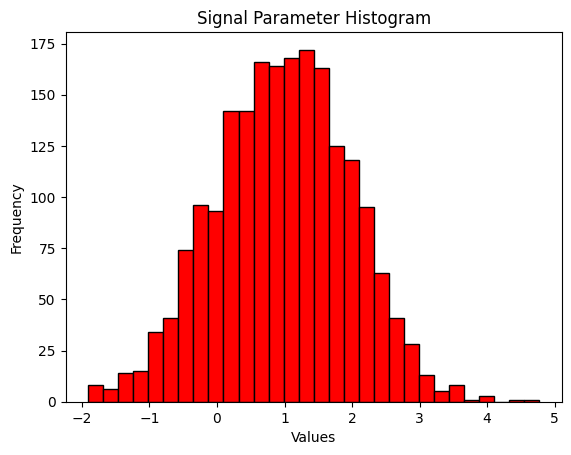

Signal Region Range:  -0.9872662  to  2.9793115


In [6]:
# define signal and sideband regions

signal_parameter = df_signal['p6']

p6_median = np.median(signal_parameter)
p6_std = np.std(signal_parameter)
print('Signal Parameter p6 median = ', p6_median)
print('Signal Parameter p6 standard deviation = ', p6_std)

plt.hist(signal_parameter, bins=30, color='red', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Signal Parameter Histogram')
plt.show()

# signal region will be defined as 1.5 standard deviations away from the median
sig_reg_low = p6_median - (2 * p6_std)
sig_reg_high = p6_median + (2 * p6_std)
print('Signal Region Range: ', sig_reg_low, ' to ', sig_reg_high)

In [7]:
## ensure event[5] matches with dataframe's p6

# print(X_train)
# print(df_background.head())

# for event in X_test:
#     if event[5] > -1.14689 and event[5] < -1.14688:
#         print(event)
#     else:
#         continue

In [8]:
# keep test set as is, adjust training and validation sets to have region labels

X_train_background_region = []
X_train_signal_region = []
X_val_background_region = []
X_val_signal_region = []

for event in X_train:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_train_background_region.append(event)
    else:
        X_train_signal_region.append(event)
for event in X_val:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_val_background_region.append(event)
    else:
        X_val_signal_region.append(event)

X_train_background_region = np.array(X_train_background_region)
X_train_signal_region = np.array(X_train_signal_region)
X_val_background_region = np.array(X_val_background_region)
X_val_signal_region = np.array(X_val_signal_region)

y_train_background_region = np.zeros((len(X_train_background_region), 1), dtype=np.float32)
y_train_signal_region = np.ones((len(X_train_signal_region), 1), dtype=np.float32)
y_val_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
y_val_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)

X_train_weak = np.vstack([X_train_background_region, X_train_signal_region]).astype(np.float32)
X_val_weak = np.vstack([X_val_background_region, X_val_signal_region]).astype(np.float32)
y_train_weak = np.concatenate((y_train_background_region, y_train_signal_region)).astype(np.float32)
y_val_weak = np.concatenate((y_val_background_region, y_val_signal_region)).astype(np.float32)

print(f"Training set has {len(X_train_weak)} events.")
print(f"Validation set has {len(X_val_weak)} events.")
print(f"Test set has {len(X_test)} events.")

Training set has 6000 events.
Validation set has 2000 events.
Test set has 2000 events.


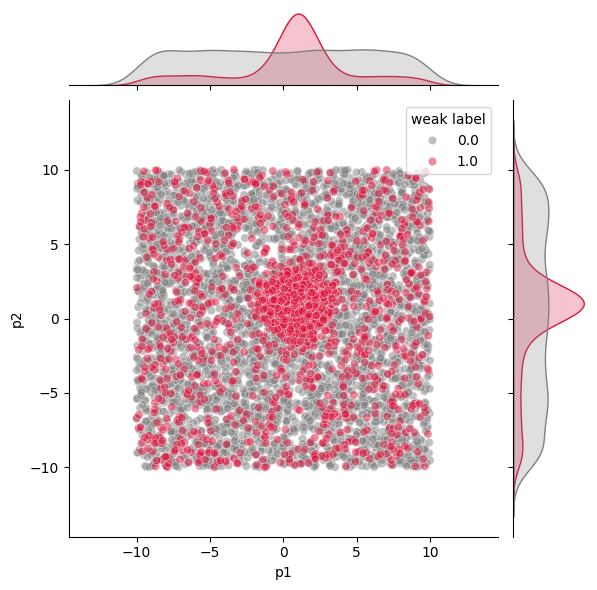

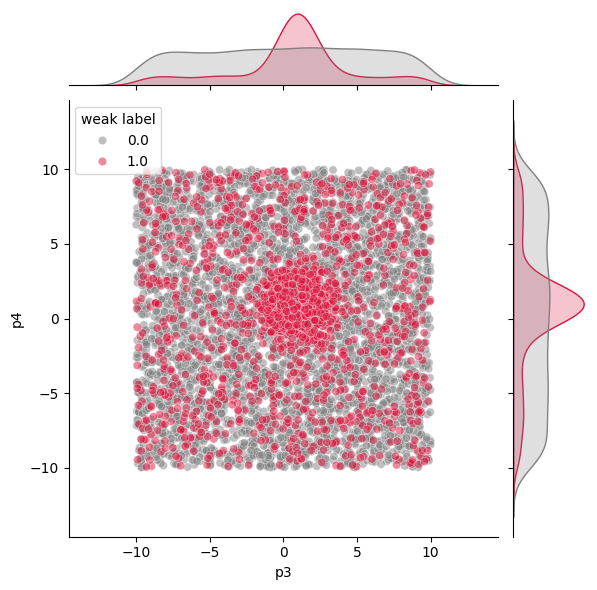

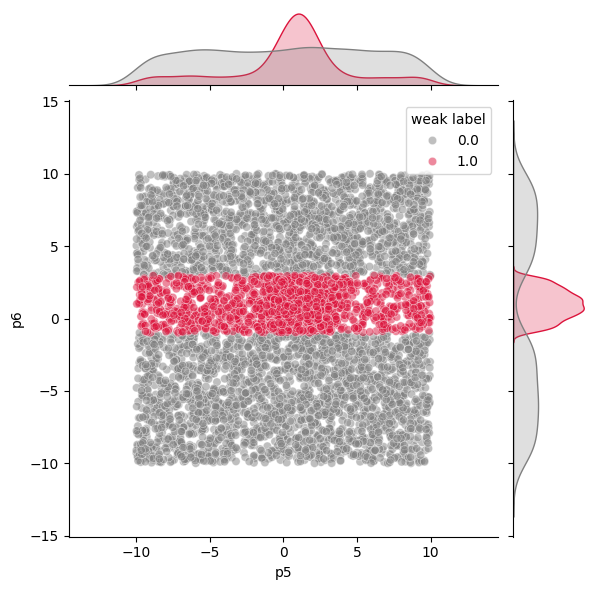

In [9]:
## visualize the regions

df = pd.DataFrame(np.column_stack([X_train_weak, y_train_weak]), columns = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'weak label'])

sns.jointplot(data=df, x="p1", y="p2", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p3", y="p4", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p5", y="p6", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [10]:
# define model, CWoLa architecture from https://arxiv.org/pdf/2305.03761

class NeuralNetwork(nn.Module): # class groups variables and functions together
    def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1): # create tool, parameters for recalling, call function is used after
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

In [11]:
# standardize data (if Gaussian shape -- multivariate normal)

### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_weak_scaled = scaler.fit_transform(X_train_weak)
X_train_weak_scaled_5 = [] # remove 6th parameter from input
for item in X_train_weak_scaled:
    item = item[0:5]
    X_train_weak_scaled_5.append(item)


### Now re-use the same transformation on validation & test sets ("transform")
X_val_weak_scaled   = scaler.transform(X_val_weak)
X_val_weak_scaled_5 = []
for item in X_val_weak_scaled:
    item = item[0:5]
    X_val_weak_scaled_5.append(item)

X_test_scaled  = scaler.transform(X_test)
X_test_scaled_5 = []
for item in X_test_scaled:
    item = item[0:5]
    X_test_scaled_5.append(item)


print("Train mean (before scaling):", np.array(X_train_weak.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_weak_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train_weak.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_weak_scaled.std(axis=0))

Train mean (before scaling): [0.13191725 0.21248777 0.24916025 0.20993288 0.21219234 0.19978695]
Train mean (after scaling) -- each dimension should be close to 0: [ 2.4552147e-08  1.0492901e-09  2.4430454e-08 -4.7733386e-09
  1.0391076e-08 -1.2671676e-07]
Train std (before scaling) [5.242783  5.2543874 5.1588025 5.2162867 5.190546  5.232802 ]
Train std (after scaling) -- each dimension should be close to 1: [1.0000002 0.9999992 0.9999995 1.        0.9999993 0.9999992]


In [12]:
# create data tensors and data loaders

X_train_weak_scaled_tensor = torch.tensor(np.array(X_train_weak_scaled_5))
y_train_weak_tensor = torch.tensor(y_train_weak)

X_val_weak_scaled_tensor = torch.tensor(np.array(X_val_weak_scaled_5))
y_val_weak_tensor = torch.tensor(y_val_weak)

X_test_scaled_tensor = torch.tensor(np.array(X_test_scaled_5))
y_test_tensor = torch.tensor(y_test)

train_weak_dataset = TensorDataset(X_train_weak_scaled_tensor, y_train_weak_tensor)
val_weak_dataset = TensorDataset(X_val_weak_scaled_tensor, y_val_weak_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_weak_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_weak_dataset, batch_size =16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

for inputs, labels in train_loader:
    print(inputs.shape, labels.shape)
    break
print(len(train_loader)) # should be 6000/16=375

torch.Size([16, 5]) torch.Size([16, 1])
375


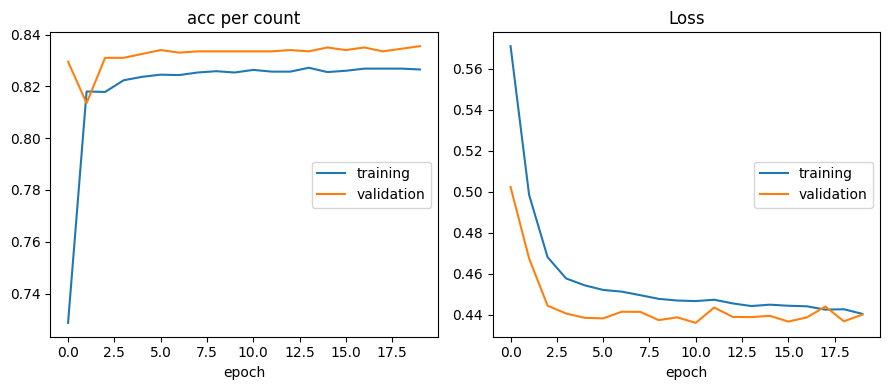

acc per count
	training         	 (min:    0.729, max:    0.827, cur:    0.827)
	validation       	 (min:    0.814, max:    0.836, cur:    0.836)
Loss
	training         	 (min:    0.440, max:    0.571, cur:    0.440)
	validation       	 (min:    0.436, max:    0.502, cur:    0.440)
Epoch 19, Loss: 0.522899329662323
Epoch 19, Accuracy: 0.8355


In [13]:
# train and validate, plot loss and accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# initialize model, loss function, optimizer
model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

# import wandb
# wandb.init(project='watch-weights')

logs = {}

for epoch in range(20):  # loop over the dataset multiple times (overfitting at 50 epochs)

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predictions = (out > 0.5).float()
        train_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss'] = train_loss_per_batch

    train_count_accuracy = train_acc / count
    logs['acc per count'] = train_count_accuracy


    # validation
    model.eval()
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        predictions = (out > 0.5).float()
        val_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss'] = val_loss_per_batch

    val_count_accuracy = val_acc / count
    logs['val_acc per count'] = val_count_accuracy

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')
    print(f'Epoch {epoch}, Accuracy: {val_count_accuracy}')

#     wandb.log({"train_loss": train_loss_per_batch, "val_loss": val_loss_per_batch, "epoch": epoch})


# wandb.finish()

Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.9480],
        [0.2549],
        [0.2759],
        [0.2343],
        [0.2002],
        [0.2282],
        [0.2633],
        [0.2067],
        [0.2380],
        [0.2505],
        [0.9623],
        [0.1930],
        [0.2759],
        [0.9692],
        [0.9624],
        [0.1251]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.]], device='cuda:0')
Average test loss: 0.2267 | Test accuracy: 0.995


(array([1.920e+02, 1.153e+03, 2.400e+02, 5.000e+00, 1.000e+00, 3.000e+00,
        4.000e+00, 1.000e+01, 2.000e+01, 3.720e+02]),
 array([0.09176596, 0.18102521, 0.27028447, 0.35954374, 0.44880301,
        0.53806227, 0.62732148, 0.71658075, 0.80584002, 0.89509928,
        0.98435855]),
 <BarContainer object of 10 artists>)

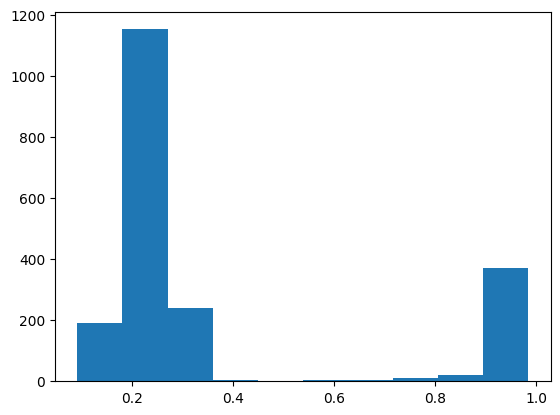

In [14]:
# run on test set, calculate AUC-ROC, list purity and completeness?

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

plt.hist(all_out)

In [15]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(all_labels, all_scores)
print(f"Test ROC-AUC (vs true labels): {auc:.3f}  (0.5 = no separation, 1.0 = perfect)")

Test ROC-AUC (vs true labels): 0.997  (0.5 = no separation, 1.0 = perfect)


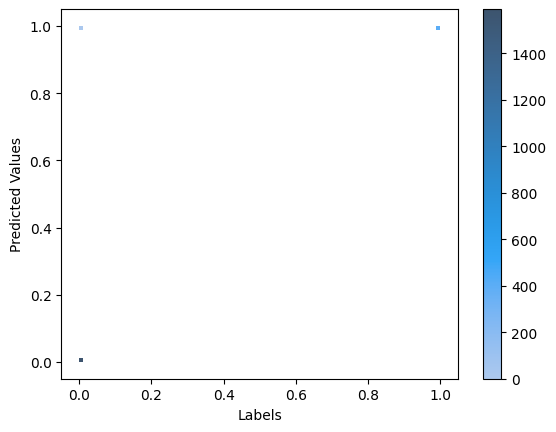

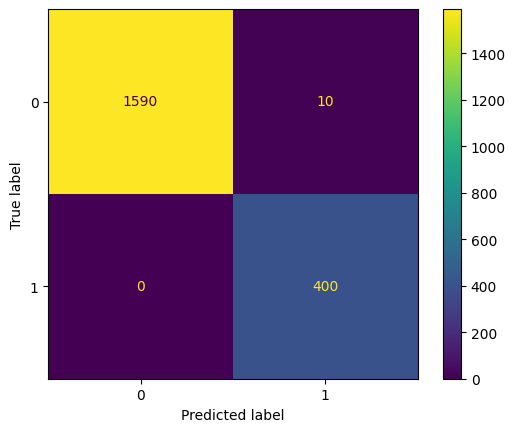

In [16]:
# make confusion matrix

data = {"Labels": all_labels, "Predicted Values": all_scores}
df = pd.DataFrame(data)

sns.histplot(data=df, x="Labels", y="Predicted Values", stat='count', cbar=True)
plt.show()

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

### Now test the limits of the CWoLa methodology on the toy dataset

In [17]:
# no signal -- inuition says that the model should fail (no anomaly to detect)

background_events = 2000 # 100% background, 0% signal
signal_events = 0 

# background distribution
X_nosig_test = np.random.uniform(low=-10, high=10, size=(background_events, 6))
X_nosig_test = np.array(X_nosig_test, dtype=np.float32)
y_nosig_test = np.zeros((len(X_nosig_test), 1), dtype=np.float32)

idx = np.random.permutation(len(X_nosig_test))
X_nosig_test = X_nosig_test[idx]
y_nosig_test = y_nosig_test[idx]


# standardize
scaler = StandardScaler()
X_nosig_test_scaled = scaler.fit_transform(X_nosig_test)
X_nosig_test_scaled_5 = [] # remove 6th parameter from input
for item in X_nosig_test_scaled:
    item = item[0:5]
    X_nosig_test_scaled_5.append(item)

print("Test mean (before scaling):", np.array(X_nosig_test.mean(axis=0)))
print("Test mean (after scaling) -- each dimension should be close to 0:", X_nosig_test_scaled.mean(axis=0))
print("Test std (before scaling)", np.array(X_nosig_test.std(axis=0)))
print("Test std (after scaling) -- each dimension should be close to 1:", X_nosig_test_scaled.std(axis=0))


X_nosig_test_scaled_tensor = torch.tensor(np.array(X_nosig_test_scaled_5))
y_nosig_test_tensor = torch.tensor(y_nosig_test)

nosig_test_dataset = TensorDataset(X_nosig_test_scaled_tensor, y_nosig_test_tensor)

nosig_test_loader = DataLoader(nosig_test_dataset, batch_size=16, shuffle=False)

for inputs, labels in nosig_test_loader:
    print(inputs.shape, labels.shape)
    break
print(len(nosig_test_loader))

Test mean (before scaling): [-0.0726729   0.02556822 -0.09358957  0.05605098  0.10044269 -0.06382568]
Test mean (after scaling) -- each dimension should be close to 0: [-9.2685219e-09 -1.4305115e-09  2.7418137e-09 -2.2649764e-09
 -2.0503998e-08 -6.8545343e-09]
Test std (before scaling) [5.7232842 5.72742   5.77678   5.7322965 5.7821507 5.6498947]
Test std (after scaling) -- each dimension should be close to 1: [0.99999976 1.0000006  1.0000005  1.0000002  0.9999998  1.0000004 ]
torch.Size([16, 5]) torch.Size([16, 1])
125


Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.1936],
        [0.2694],
        [0.2089],
        [0.1864],
        [0.1641],
        [0.2098],
        [0.2380],
        [0.2346],
        [0.2071],
        [0.2656],
        [0.2369],
        [0.2256],
        [0.2336],
        [0.2495],
        [0.2480],
        [0.2820]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')
Average test loss: 0.2785 | Test accuracy: 0.992


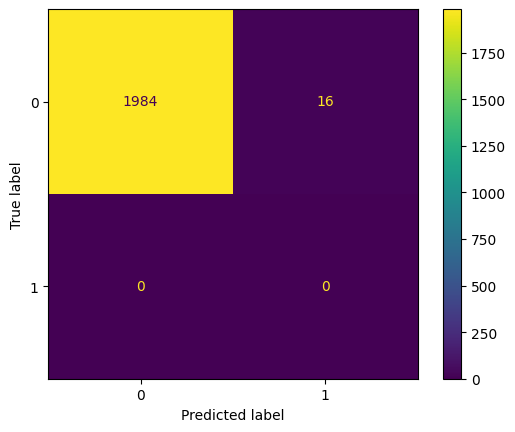

(array([2.830e+02, 1.524e+03, 1.600e+02, 1.200e+01, 7.000e+00, 4.000e+00,
        5.000e+00, 1.000e+00, 2.000e+00, 2.000e+00]),
 array([0.10910457, 0.19612333, 0.28314209, 0.37016085, 0.45717961,
        0.54419839, 0.63121712, 0.71823591, 0.80525464, 0.89227337,
        0.97929215]),
 <BarContainer object of 10 artists>)

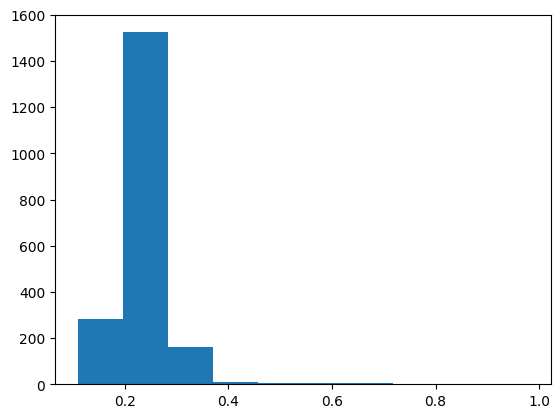

In [18]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in nosig_test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [19]:
# 50/50 signal background

background_events = 1000 # 50% background, 50% signal
signal_events = 1000

# background distribution
X_50b_test = np.random.uniform(low=-10, high=10, size=(background_events, 6))
X_50b_test = np.array(X_50b_test, dtype=np.float32)
y_50b_test = np.zeros((len(X_50b_test), 1), dtype=np.float32)


# signal distribution
mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
cov_s = np.eye(6) # identity matrix for covariance
X_50sig_test = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
X_50sig_test = np.array(X_50sig_test, dtype=np.float32)
y_50sig_test = np.ones((len(X_50sig_test), 1), dtype=np.float32)

print(f"Background test set has {len(X_50b_test)} events.")
print(f"Signal test set has {len(X_50sig_test)} events.")

X_5050_test = np.vstack([X_50b_test, X_50sig_test])
y_5050_test = np.concatenate([y_50b_test, y_50sig_test])

idx = np.random.permutation(len(X_5050_test))
X_5050_test = X_5050_test[idx]
y_5050_test = y_5050_test[idx]


# standardize
scaler = StandardScaler()
X_5050_test_scaled = scaler.fit_transform(X_5050_test)
X_5050_test_scaled_5 = [] # remove 6th parameter from input
for item in X_5050_test_scaled:
    item = item[0:5]
    X_5050_test_scaled_5.append(item)


X_5050_test_scaled_tensor = torch.tensor(np.array(X_5050_test_scaled_5))
y_5050_test_tensor = torch.tensor(y_5050_test)

test5050_dataset = TensorDataset(X_5050_test_scaled_tensor, y_5050_test_tensor)

test5050_loader = DataLoader(test5050_dataset, batch_size=16, shuffle=False)

Background test set has 1000 events.
Signal test set has 1000 events.


Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.2513],
        [0.2326],
        [0.9277],
        [0.2516],
        [0.9478],
        [0.9574],
        [0.9686],
        [0.1675],
        [0.2082],
        [0.3154],
        [0.1329],
        [0.9743],
        [0.9709],
        [0.8502],
        [0.2534],
        [0.8472]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.]], device='cuda:0')
Average test loss: 0.1808 | Test accuracy: 0.992


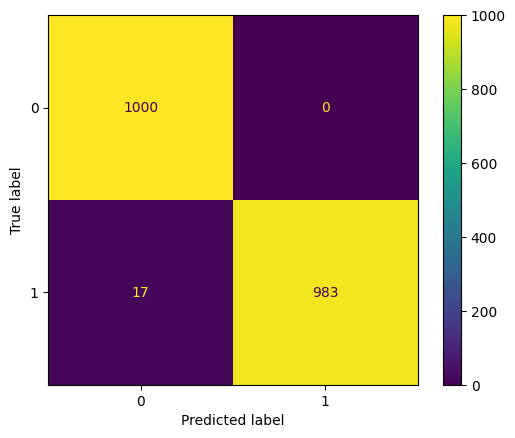

(array([106., 654., 244.,   8.,  12.,  17.,  22.,  40., 126., 771.]),
 array([0.07172693, 0.16301866, 0.25431037, 0.3456021 , 0.43689382,
        0.52818555, 0.61947727, 0.710769  , 0.80206072, 0.89335245,
        0.98464417]),
 <BarContainer object of 10 artists>)

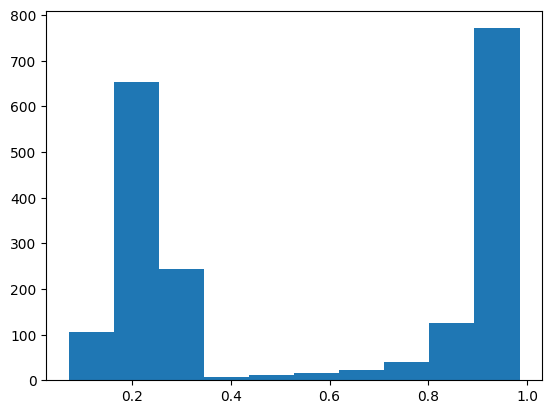

In [20]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in test5050_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [21]:
# all signal

background_events = 0 # 0% background, 100% signal
signal_events = 2000


# signal distribution
mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
cov_s = np.eye(6) # identity matrix for covariance
X_allsig_test = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
X_allsig_test = np.array(X_allsig_test, dtype=np.float32)
y_allsig_test = np.ones((len(X_allsig_test), 1), dtype=np.float32)

print(f"Test set has {len(X_allsig_test)} events.")

idx = np.random.permutation(len(X_allsig_test))
X_allsig_test = X_allsig_test[idx]
y_allsig_test = y_allsig_test[idx]


# standardize
scaler = StandardScaler()
X_allsig_test_scaled = scaler.fit_transform(X_allsig_test)
X_allsig_test_scaled_5 = [] # remove 6th parameter from input
for item in X_allsig_test_scaled:
    item = item[0:5]
    X_allsig_test_scaled_5.append(item)


X_allsig_test_scaled_tensor = torch.tensor(np.array(X_allsig_test_scaled_5))
y_allsig_test_tensor = torch.tensor(y_allsig_test)

allsig_test_dataset = TensorDataset(X_allsig_test_scaled_tensor, y_allsig_test_tensor)

allsig_test_loader = DataLoader(allsig_test_dataset, batch_size=16, shuffle=False)

Test set has 2000 events.


Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.2592],
        [0.2078],
        [0.2123],
        [0.2364],
        [0.2770],
        [0.3374],
        [0.2190],
        [0.2398],
        [0.2465],
        [0.2814],
        [0.2574],
        [0.2178],
        [0.2150],
        [0.2235],
        [0.1742],
        [0.2581]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')
Average test loss: 1.4311 | Test accuracy: 0.025


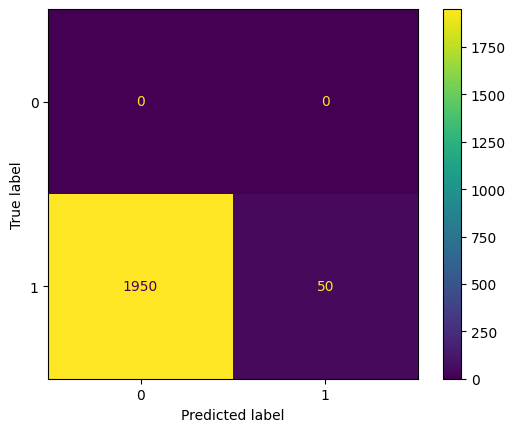

(array([  66., 1271.,  576.,   28.,   15.,    5.,   13.,    8.,   10.,
           8.]),
 array([0.07047887, 0.16106969, 0.25166053, 0.3422513 , 0.43284214,
        0.52343297, 0.61402375, 0.70461458, 0.79520541, 0.88579625,
        0.97638708]),
 <BarContainer object of 10 artists>)

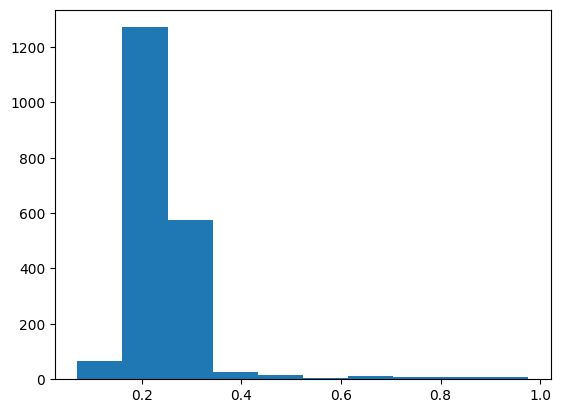

In [22]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in allsig_test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [23]:
# signal/background regions not matching data

idx = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

idx = np.random.permutation(len(X_val))
X_val = X_val[idx]
y_val = y_val[idx]

idx = np.random.permutation(len(X_test))
X_test = X_test[idx]
y_test = y_test[idx]

print(f"Background training set has {len(Xb_train)} events.")
print(f"Background validation set has {len(Xb_val)} events.")
print(f"Background test set has {len(Xb_test)} events.")
print(f"Signal training set has {len(Xs_train)} events.")
print(f"Signal validation set has {len(Xs_val)} events.")
print(f"Signal test set has {len(Xs_test)} events.")

Background training set has 4800 events.
Background validation set has 1600 events.
Background test set has 1600 events.
Signal training set has 1200 events.
Signal validation set has 400 events.
Signal test set has 400 events.


Signal Parameter p6 median =  0.9960226
Signal Parameter p6 standard deviation =  0.9916444


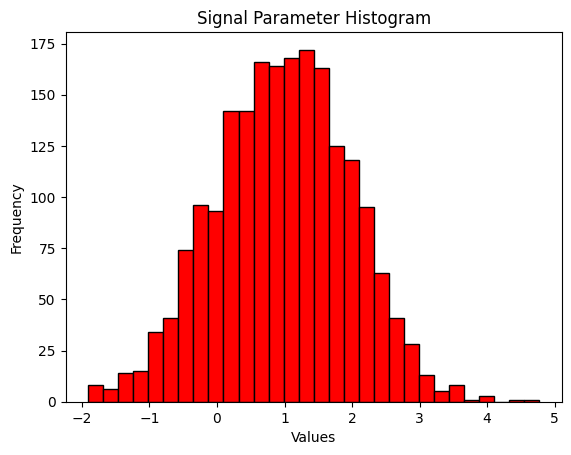

Signal Region Range:  2.9793115  to  6.945889


In [24]:
# redefine signal and sideband regions

signal_parameter = df_signal['p6']

p6_median = np.median(signal_parameter)
p6_std = np.std(signal_parameter)
print('Signal Parameter p6 median = ', p6_median)
print('Signal Parameter p6 standard deviation = ', p6_std)

plt.hist(signal_parameter, bins=30, color='red', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Signal Parameter Histogram')
plt.show()

# signal region will be defined as 3-5 standard deviations away from the median
sig_reg_low = p6_median + (2 * p6_std)
sig_reg_high = p6_median + (6 * p6_std)
print('Signal Region Range: ', sig_reg_low, ' to ', sig_reg_high)

In [25]:
# keep test set as is, adjust training and validation sets to have region labels

X_train_background_region = []
X_train_signal_region = []
X_val_background_region = []
X_val_signal_region = []

for event in X_train:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_train_background_region.append(event)
    else:
        X_train_signal_region.append(event)
for event in X_val:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_val_background_region.append(event)
    else:
        X_val_signal_region.append(event)

X_train_background_region = np.array(X_train_background_region)
X_train_signal_region = np.array(X_train_signal_region)
X_val_background_region = np.array(X_val_background_region)
X_val_signal_region = np.array(X_val_signal_region)

y_train_background_region = np.zeros((len(X_train_background_region), 1), dtype=np.float32)
y_train_signal_region = np.ones((len(X_train_signal_region), 1), dtype=np.float32)
y_val_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
y_val_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)

X_train_weak = np.vstack([X_train_background_region, X_train_signal_region]).astype(np.float32)
X_val_weak = np.vstack([X_val_background_region, X_val_signal_region]).astype(np.float32)
y_train_weak = np.concatenate((y_train_background_region, y_train_signal_region)).astype(np.float32)
y_val_weak = np.concatenate((y_val_background_region, y_val_signal_region)).astype(np.float32)

print(f"Training set has {len(X_train_weak)} events.")
print(f"Validation set has {len(X_val_weak)} events.")
print(f"Test set has {len(X_test)} events.")

Training set has 6000 events.
Validation set has 2000 events.
Test set has 2000 events.


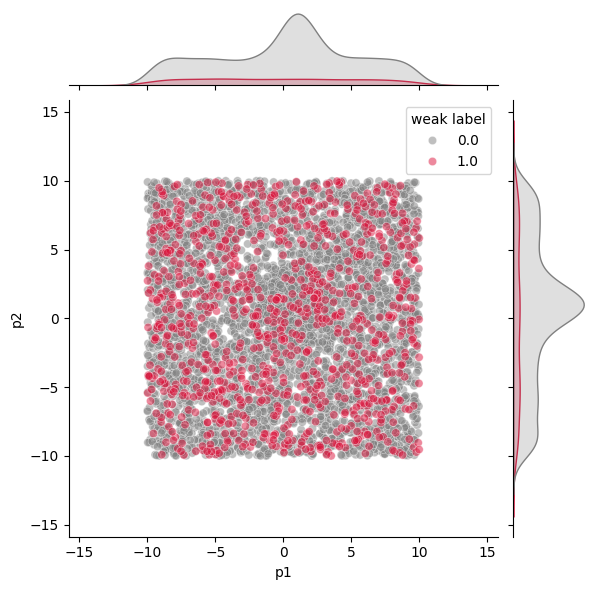

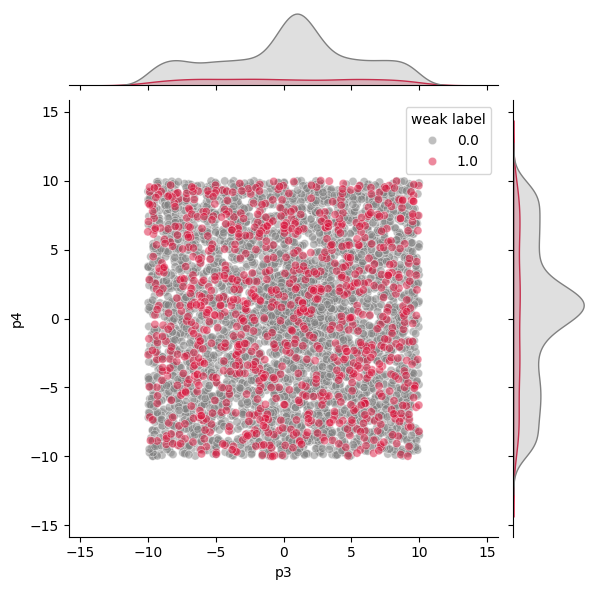

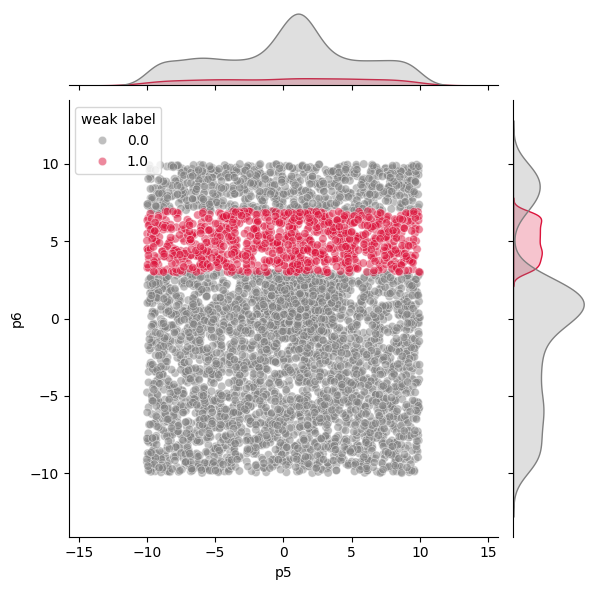

In [26]:
## visualize the regions

df = pd.DataFrame(np.column_stack([X_train_weak, y_train_weak]), columns = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'weak label'])

sns.jointplot(data=df, x="p1", y="p2", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p3", y="p4", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p5", y="p6", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [27]:
### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_weak_scaled = scaler.fit_transform(X_train_weak)
X_train_weak_scaled_5 = [] # remove 6th parameter from input
for item in X_train_weak_scaled:
    item = item[0:5]
    X_train_weak_scaled_5.append(item)


### Now re-use the same transformation on validation & test sets ("transform")
X_val_weak_scaled   = scaler.transform(X_val_weak)
X_val_weak_scaled_5 = []
for item in X_val_weak_scaled:
    item = item[0:5]
    X_val_weak_scaled_5.append(item)

X_test_scaled  = scaler.transform(X_test)
X_test_scaled_5 = []
for item in X_test_scaled:
    item = item[0:5]
    X_test_scaled_5.append(item)


print("Train mean (before scaling):", np.array(X_train_weak.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_weak_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train_weak.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_weak_scaled.std(axis=0))

Train mean (before scaling): [0.13191734 0.21248794 0.24916095 0.20993327 0.21219252 0.1997875 ]
Train mean (after scaling) -- each dimension should be close to 0: [ 4.7286353e-09 -3.4076471e-08 -9.1393790e-09  4.3412052e-09
 -1.9162893e-08  1.2276570e-07]
Train std (before scaling) [5.2427826 5.254391  5.158808  5.216282  5.190551  5.232796 ]
Train std (after scaling) -- each dimension should be close to 1: [0.9999996 1.0000004 1.0000011 0.9999995 0.9999994 0.9999998]


In [28]:
# create data tensors and data loaders

X_train_weak_scaled_tensor = torch.tensor(np.array(X_train_weak_scaled_5))
y_train_weak_tensor = torch.tensor(y_train_weak)

X_val_weak_scaled_tensor = torch.tensor(np.array(X_val_weak_scaled_5))
y_val_weak_tensor = torch.tensor(y_val_weak)

X_test_scaled_tensor = torch.tensor(np.array(X_test_scaled_5))
y_test_tensor = torch.tensor(y_test)

train_weak_dataset = TensorDataset(X_train_weak_scaled_tensor, y_train_weak_tensor)
val_weak_dataset = TensorDataset(X_val_weak_scaled_tensor, y_val_weak_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_weak_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_weak_dataset, batch_size =16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

for inputs, labels in train_loader:
    print(inputs.shape, labels.shape)
    break
print(len(train_loader))

torch.Size([16, 5]) torch.Size([16, 1])
375


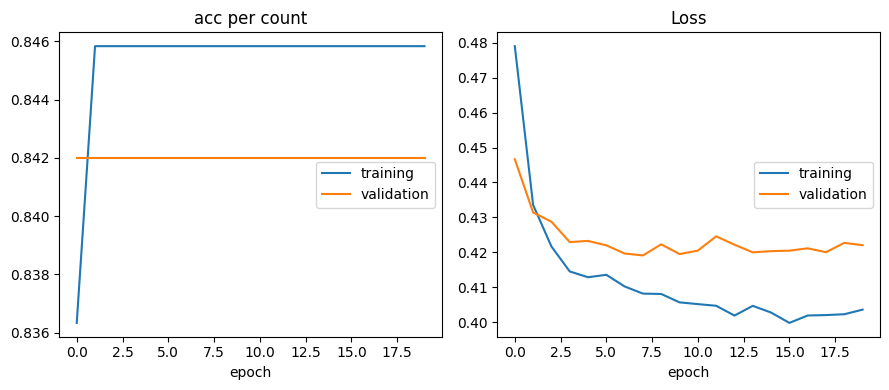

acc per count
	training         	 (min:    0.836, max:    0.846, cur:    0.846)
	validation       	 (min:    0.842, max:    0.842, cur:    0.842)
Loss
	training         	 (min:    0.400, max:    0.479, cur:    0.404)
	validation       	 (min:    0.419, max:    0.447, cur:    0.422)
Epoch 19, Loss: 1.5498347282409668
Epoch 19, Accuracy: 0.842


In [29]:
# train and validate, plot loss and accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# initialize model, loss function, optimizer
model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

# import wandb
# wandb.init(project='watch-weights')

logs = {}

for epoch in range(20):  # loop over the dataset multiple times (overfitting at 50 epochs)

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predictions = (out > 0.5).float()
        train_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss'] = train_loss_per_batch

    train_count_accuracy = train_acc / count
    logs['acc per count'] = train_count_accuracy


    # validation
    model.eval()
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        predictions = (out > 0.5).float()
        val_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss'] = val_loss_per_batch

    val_count_accuracy = val_acc / count
    logs['val_acc per count'] = val_count_accuracy

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')
    print(f'Epoch {epoch}, Accuracy: {val_count_accuracy}')

#     wandb.log({"train_loss": train_loss_per_batch, "val_loss": val_loss_per_batch, "epoch": epoch})


# wandb.finish()

Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.1748],
        [0.0144],
        [0.1864],
        [0.0134],
        [0.2309],
        [0.1873],
        [0.1770],
        [0.1760],
        [0.0470],
        [0.2446],
        [0.0154],
        [0.1640],
        [0.2719],
        [0.1699],
        [0.1331],
        [0.0087]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')
Average test loss: 1.0375 | Test accuracy: 0.800


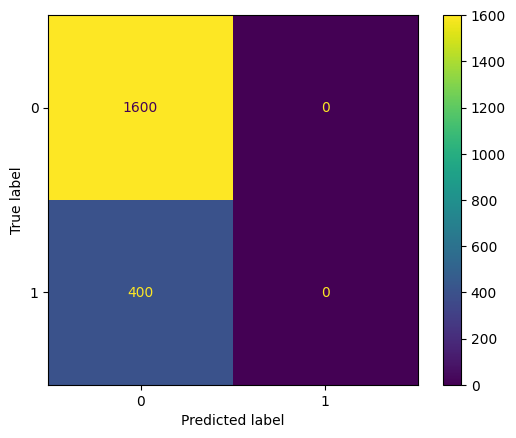

(array([399.,  12.,   9.,  30., 137., 337., 479., 364., 184.,  49.]),
 array([0.00842883, 0.03861677, 0.06880472, 0.09899266, 0.12918061,
        0.15936854, 0.18955649, 0.21974443, 0.24993238, 0.28012034,
        0.31030828]),
 <BarContainer object of 10 artists>)

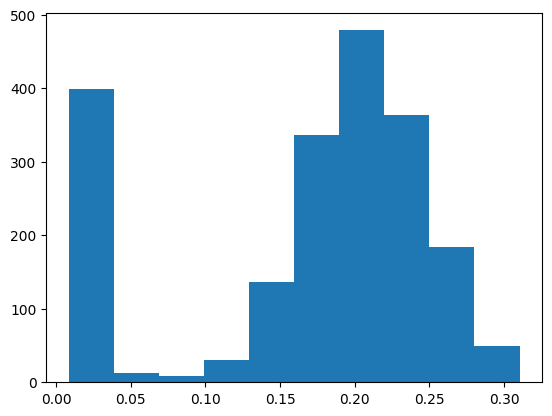

In [30]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [32]:
### OBSERVATIONS

# no signal: worked, assumed all is background
# all signal: broke, makes sense to assume all is background (no anomaly)
# signal band defined elsewhere: model guessed all background and therefore got 80% accuracy